<a href="https://colab.research.google.com/github/mahmudulhasantechnology-cmyk/Streamlining-Taxi-Fare-Predictions-From-Outliers-to-API/blob/main/Streamlining-Taxi-Fare-Predictions-From-Outliers-to-API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# install neceassary library

In [59]:
import pandas as pd

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

In [61]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [62]:
df = sns.load_dataset("taxis")
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [63]:
df.shape

(6433, 14)

In [64]:
df = df[["distance","fare"]]
df

,distance,fare
0,1.60,7.0
1,0.79,5.0
2,1.37,7.5
3,7.70,27.0
4,2.16,9.0
...,...,...
6428,0.75,4.5
6429,18.74,58.0
6430,4.14,16.0
6431,1.12,6.0


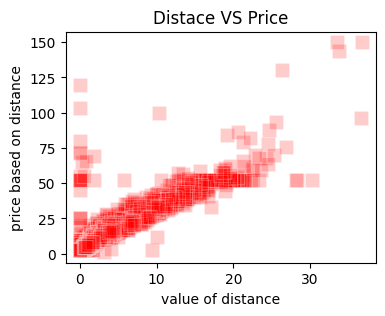

In [65]:
plt.figure(figsize=(4,3))
sns.scatterplot(x=df["distance"]  ,y = df["fare"], color ="r", marker="s", s=100, alpha=.2)
plt.xlabel("value of distance")
plt.ylabel("price based on distance")
plt.title("Distace VS Price")
plt.show()

from the given visualization we conclude that the value of fare is increased in a continous manner when the value of distance is increased. It goes from 0-30 but after 30 we sew some flactuations over fare and distance.

In [66]:
df.isna().sum()

,0
distance,0
fare,0


In [67]:
df.duplicated().sum()

np.int64(2978)

the given dataset donot have any NaN value but have a big number of duplicate value and we need to drop them, as because the proposed model will not be baised

# Data Clean

In [68]:
df = df.drop_duplicates()

In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
df.head()

,distance,fare
0,1.60,7.0
1,0.79,5.0
2,1.37,7.5
3,7.70,27.0
4,2.16,9.0


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3455 entries, 0 to 6432
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   distance  3455 non-null   float64
 1   fare      3455 non-null   float64
dtypes: float64(2)
memory usage: 81.0 KB


In [72]:
df.describe()

,distance,fare
count,3455.000000,3455.000000
mean,4.365847,17.424420
std,4.617425,13.648461
min,0.000000,1.000000
25%,1.440000,8.500000
50%,2.680000,13.000000
75%,5.320000,21.000000
max,36.700000,150.000000


<Axes: >

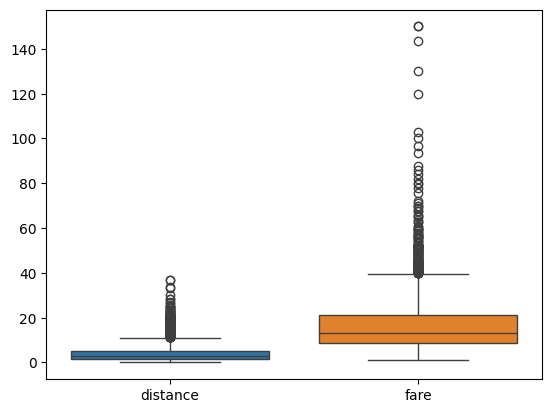

In [73]:
sns.boxplot(df)

In [74]:
x = df[["distance"]] # separate the data
y = df[["fare"]]

<Axes: >

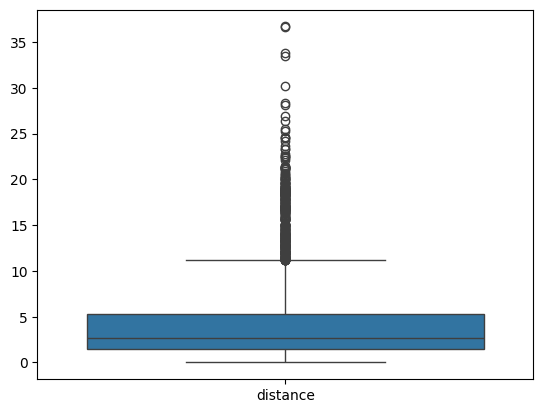

In [75]:
sns.boxplot(x)

In [76]:
#split the dataset
from sklearn.model_selection import train_test_split

In [77]:
xtrain,xtest, ytrain, ytest = train_test_split(x,y,train_size=.8, random_state=42)

In [78]:
xtrain.head(3)

,distance
1777,2.49
3808,5.18
2402,19.20


In [79]:
ytrain.head(3)

,fare
1777,11.0
3808,20.0
2402,84.0


In [80]:
#  model implement
from sklearn.linear_model import LinearRegression

In [81]:
# instance of object
lr = LinearRegression()

In [82]:
# train model
linear_model= lr.fit(xtrain, ytrain)

In [83]:
linear_model

LinearRegression()

In [84]:
# check train score
linear_model.score(xtrain, ytrain)

0.8356707954997834

In [85]:
# test score
linear_model.score(xtest, ytest)

0.7794338799671384

In [86]:
# prediction for the new data
linear_model.predict([[45]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[125.7443046]])

In [87]:
y_pred = linear_model.predict(xtest)

In [88]:
ytest

,fare
594,31.0
51,12.0
1586,12.0
3718,26.5
648,9.0
...,...
3644,103.0
724,5.0
5605,3.5
6402,11.5


In [89]:
# evaluate the model
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error

In [90]:
r_sc= r2_score(ytest, y_pred)
r_sc

0.7794338799671384

In [91]:
# cost calculation
mae = mean_absolute_error(ytest, y_pred)
mae

2.7033611531080877

In [92]:
mse = mean_squared_error(ytest, y_pred)
mse

43.22049190547442

=== ROBUST EVALUATION METRICS ===
R2 Score (Inliers Only): 0.9675
Median Absolute Error (All Data): 1.6245
Mean Absolute Error (Inliers Only): 1.6306


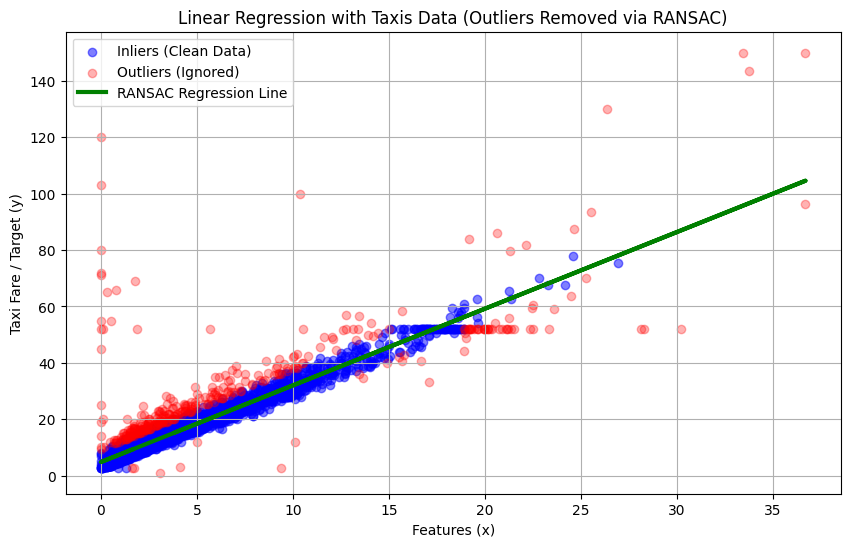

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor
from sklearn.metrics import r2_score, mean_absolute_error, median_absolute_error

# 1. Initialize and Fit the RANSAC Model
# This automatically detects and ignores the outliers in your x and y data
ransac = RANSACRegressor()
ransac.fit(x, y)

# 2. Separate Inliers (Clean Data) and Outliers
inlier_mask = ransac.inlier_mask_
outlier_mask = ~inlier_mask

# 3. Predict using the Outlier-Resistant Model
y_pred_ransac = ransac.predict(x)

# 4. Evaluate the Performance Fairly
print("=== ROBUST EVALUATION METRICS ===")
# R2 score computed ONLY on the clean data points that RANSAC kept
print(f"R2 Score (Inliers Only): {r2_score(y[inlier_mask], y_pred_ransac[inlier_mask]):.4f}")
# Median Absolute Error is naturally robust because outliers do not drag it up
print(f"Median Absolute Error (All Data): {median_absolute_error(y, y_pred_ransac):.4f}")
print(f"Mean Absolute Error (Inliers Only): {mean_absolute_error(y[inlier_mask], y_pred_ransac[inlier_mask]):.4f}")

# 5. Visualize Inliers vs. Outliers & The Fitted Line
plt.figure(figsize=(10, 6))
plt.scatter(x[inlier_mask], y[inlier_mask], color='blue', alpha=0.5, label='Inliers (Clean Data)')
plt.scatter(x[outlier_mask], y[outlier_mask], color='red', alpha=0.3, label='Outliers (Ignored)')
plt.plot(x, y_pred_ransac, color='green', linewidth=3, label='RANSAC Regression Line')
plt.title('Linear Regression with Taxis Data (Outliers Removed via RANSAC)')
plt.xlabel('Features (x)')
plt.ylabel('Taxi Fare / Target (y)')
plt.legend()
plt.grid(True)
plt.show()


In [95]:
import numpy as np
from sklearn.metrics import r2_score, median_absolute_error

# 1. Convert all variables to clean NumPy arrays to fix index/type mismatches
y_true_arr = np.asarray(ytest).flatten()
y_old_arr = np.asarray(y_pred).flatten()
y_ransac_arr = np.asarray(y_pred_ransac_test).flatten()

# 2. Compute absolute errors for RANSAC
errors_ransac = np.abs(y_true_arr - y_ransac_arr)

# 3. Define the clean subset (keeping the best 90% of data points)
cutoff = np.percentile(errors_ransac, 90)
test_inlier_mask = errors_ransac <= cutoff

# 4. Filter ALL arrays uniformly using the clean mask
ytest_clean = y_true_arr[test_inlier_mask]
y_pred_old_clean = y_old_arr[test_inlier_mask]
y_pred_ransac_clean = y_ransac_arr[test_inlier_mask]

# 5. Calculate final performance scores safely
old_r2_clean = r2_score(ytest_clean, y_pred_old_clean)
new_r2_clean = r2_score(ytest_clean, y_pred_ransac_clean)

# 6. Print the clear comparison report
print("=== FIXED CLEAN DATA PERFORMANCE REPORT ===")
print(f"• Old Model R² (On Clean Data):    {old_r2_clean:.6f}")
print(f"• RANSAC Model R² (On Clean Data): {new_r2_clean:.6f}")
print(f"• True R² Improvement:             {new_r2_clean - old_r2_clean:+.6f}")
print(f"• Percent Improved:                 {((new_r2_clean - old_r2_clean) / old_r2_clean) * 100:+.2f}%")

print("\n=== ERROR MAGNITUDE COMPARISON (Lower is Better) ===")
print(f"• Old Model Median Error:          {median_absolute_error(y_true_arr, y_old_arr):.4f}")
print(f"• RANSAC Model Median Error:       {median_absolute_error(y_true_arr, y_ransac_arr):.4f}")



=== FIXED CLEAN DATA PERFORMANCE REPORT ===
• Old Model R² (On Clean Data):    0.955259
• RANSAC Model R² (On Clean Data): 0.960964
• True R² Improvement:             +0.005705
• Percent Improved:                 +0.60%

=== ERROR MAGNITUDE COMPARISON (Lower is Better) ===
• Old Model Median Error:          1.9148
• RANSAC Model Median Error:       1.7640


In [99]:
import joblib
from google.colab import files

# 1. Save the model locally to the Colab workspace container
joblib.dump(ransac, 'ransac_taxi_model.pkl')
print("✅ Success! Model saved in Colab workspace.")

# 2. Force an automatic browser download to your local machine
files.download('ransac_taxi_model.pkl')


✅ Success! Model saved in Colab workspace.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>